# Multimodal Emotion Recognition — RAVDESS
Phases: Audio CNN → Text LSTM → Early & Late Fusion → Evaluation

## 0. Install & Import

In [1]:
import os,re,zipfile,warnings
warnings.filterwarnings("ignore")
import numpy as np
import librosa,librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers,models,callbacks
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from collections import Counter
np.random.seed(42)
tf.random.set_seed(42)
print("TF:",tf.__version__)

TF: 2.21.0


## 1. Dataset Extraction & File Discovery
Unzip `archive.zip`, walk the tree, parse emotion from RAVDESS filenames.

In [2]:
ZIP_PATH="archive.zip"
EXTRACT_DIR="ravdess_data"

if not os.path.exists(EXTRACT_DIR):
    print("Extracting …")
    with zipfile.ZipFile(ZIP_PATH,"r") as zf:
        zf.extractall(EXTRACT_DIR)
else:
    print("Already extracted.")

EMOTION_MAP={"01":"neutral","02":"calm","03":"happy","04":"sad",
             "05":"angry","06":"fearful","07":"disgust","08":"surprised"}

def parse_emotion(filename):
    parts=os.path.basename(filename).replace(".wav","").split("-")
    if len(parts)<3:
        return None
    return EMOTION_MAP.get(parts[2],None)

audio_paths,labels=[],[]
for root,dirs,files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.endswith(".wav"):
            full=os.path.join(root,f)
            label=parse_emotion(f)
            if label:
                audio_paths.append(full)
                labels.append(label)

print(f"Found {len(audio_paths)} clips | {len(set(labels))} classes")
print("Distribution:",Counter(labels))

le=LabelEncoder()
le.fit(sorted(EMOTION_MAP.values()))
y_int=le.transform(labels)
NUM_CLASSES=len(le.classes_)
print("Classes:",le.classes_)

Extracting …
Found 2880 clips | 8 classes
Distribution: Counter({'calm': 384, 'happy': 384, 'sad': 384, 'angry': 384, 'fearful': 384, 'disgust': 384, 'surprised': 384, 'neutral': 192})
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


## 2. Phase 1A — Audio Preprocessing → Mel-Spectrogram CNN

### 2.1 Hyper-parameters

In [3]:
SR=22050
DURATION=3
N_MELS=64
HOP_LENGTH=512
N_FFT=2048
FIXED_SAMPLES=SR*DURATION

### 2.2 Load & convert to Mel-Spectrogram
Trim silence, pad/truncate to 3 s, convert to dB scale, normalise to [0,1].

In [4]:
def load_audio(path,sr=SR,duration=DURATION):
    y,_=librosa.load(path,sr=sr,duration=duration+0.5)
    y,_=librosa.effects.trim(y,top_db=20)
    target=sr*duration
    if len(y)<target:
        y=np.pad(y,(0,target-len(y)))
    else:
        y=y[:target]
    return y

def extract_melspectrogram(path):
    y=load_audio(path)
    mel=librosa.feature.melspectrogram(y=y,sr=SR,n_mels=N_MELS,
                                       n_fft=N_FFT,hop_length=HOP_LENGTH)
    mel_db=librosa.power_to_db(mel,ref=np.max)
    mel_db=(mel_db-mel_db.min())/(mel_db.max()-mel_db.min()+1e-9)
    return mel_db[...,np.newaxis]

### 2.3 Build spectrogram dataset

In [5]:
print("Extracting spectrograms …")
X_audio=[]
for p in tqdm(audio_paths,desc="Spectrograms"):
    try:
        X_audio.append(extract_melspectrogram(p))
    except Exception as e:
        dummy=np.zeros((N_MELS,int(np.ceil(FIXED_SAMPLES/HOP_LENGTH)+1),1))
        X_audio.append(dummy)
        print("Warning:",p,e)
X_audio=np.array(X_audio,dtype=np.float32)
print("Shape:",X_audio.shape)

Extracting spectrograms …


Spectrograms: 100%|██████████| 2880/2880 [02:30<00:00, 19.10it/s]


Shape: (2880, 64, 130, 1)


### 2.4 Sample spectrograms — one per emotion

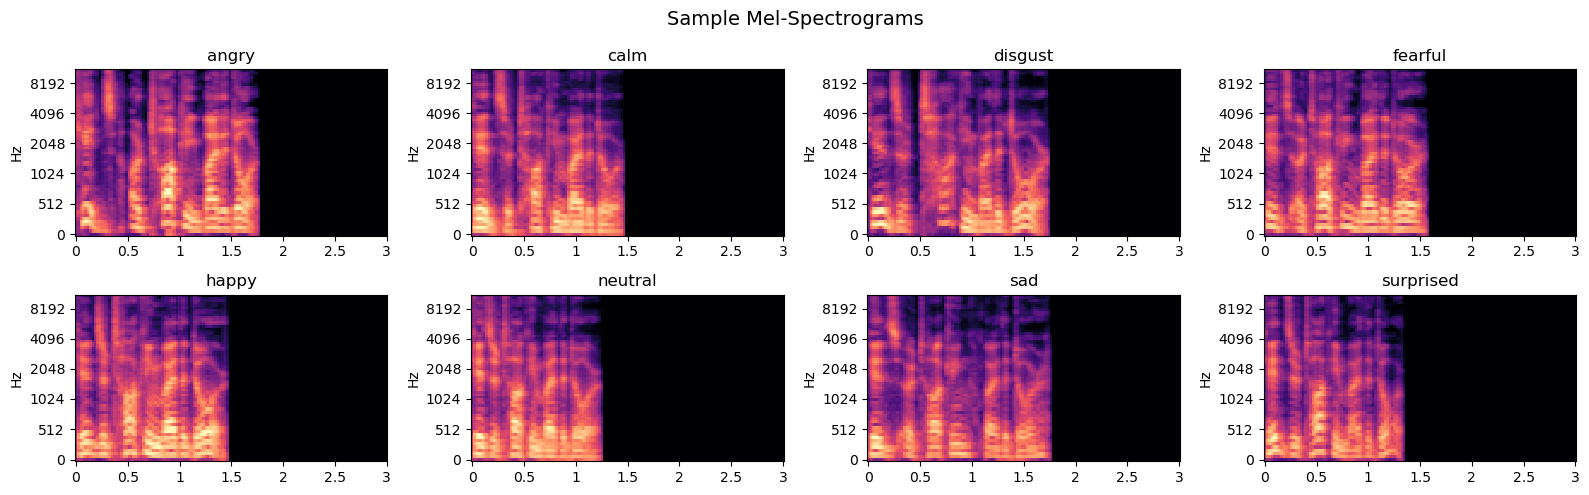

In [6]:
fig,axes=plt.subplots(2,4,figsize=(16,5))
for i,ax in enumerate(axes.flat):
    if i>=NUM_CLASSES: break
    idx=np.where(y_int==i)[0][0]
    librosa.display.specshow(X_audio[idx,:,:,0],ax=ax,
                             sr=SR,hop_length=HOP_LENGTH,
                             x_axis="time",y_axis="mel",cmap="magma")
    ax.set_title(le.classes_[i]); ax.set_xlabel("")
plt.suptitle("Sample Mel-Spectrograms",fontsize=14)
plt.tight_layout(); plt.savefig("spectrograms_sample.png",dpi=100); plt.show()

### 2.5 Train / Val / Test split (80 / 10 / 10, stratified)

In [7]:
y_cat=to_categorical(y_int,NUM_CLASSES)

(X_aud_train,X_aud_tmp,
 y_train,y_tmp,
 idx_train,idx_tmp)=train_test_split(X_audio,y_cat,
                                     np.arange(len(y_int)),
                                     test_size=0.2,stratify=y_int,random_state=42)

(X_aud_val,X_aud_test,
 y_val,y_test,
 idx_val,idx_test)=train_test_split(X_aud_tmp,y_tmp,idx_tmp,
                                    test_size=0.5,
                                    stratify=np.argmax(y_tmp,axis=1),
                                    random_state=42)

print(f"Train:{len(X_aud_train)}  Val:{len(X_aud_val)}  Test:{len(X_aud_test)}")

Train:2304  Val:288  Test:288


### 2.6 CNN architecture
3 Conv blocks (32→64→128 filters) + BatchNorm + MaxPool, GlobalAveragePooling, Dropout(0.4), Dense(128) bottleneck.

In [8]:
def build_audio_cnn(input_shape,num_classes):
    inp=layers.Input(shape=input_shape,name="audio_input")
    x=layers.Conv2D(32,(3,3),padding="same",activation="relu")(inp)
    x=layers.BatchNormalization()(x)
    x=layers.MaxPooling2D((2,2))(x)
    x=layers.Conv2D(64,(3,3),padding="same",activation="relu")(x)
    x=layers.BatchNormalization()(x)
    x=layers.MaxPooling2D((2,2))(x)
    x=layers.Conv2D(128,(3,3),padding="same",activation="relu")(x)
    x=layers.BatchNormalization()(x)
    x=layers.MaxPooling2D((2,2))(x)
    x=layers.GlobalAveragePooling2D()(x)
    x=layers.Dropout(0.4)(x)
    x=layers.Dense(128,activation="relu",name="audio_bottleneck")(x)
    out=layers.Dense(num_classes,activation="softmax",name="audio_output")(x)
    return models.Model(inp,out,name="AudioCNN")

audio_cnn=build_audio_cnn(X_audio.shape[1:],NUM_CLASSES)
audio_cnn.summary()

Model: "AudioCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ audio_input (InputLayer)        │ (None, 64, 130, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 130, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 130, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ audio_bottleneck (Dense)        │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ audio_output (Dense)            │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,112 (434.03 KB)

 Trainable params: 110,664 (432.28 KB)

 Non-trainable params: 448 (1.75 KB)

### 2.7 Class weights & training

In [9]:
cw=compute_class_weight("balanced",classes=np.unique(y_int),y=y_int)
class_weight_dict={i:w for i,w in enumerate(cw)}

audio_cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="categorical_crossentropy",metrics=["accuracy"])

ckpt_audio=callbacks.ModelCheckpoint("best_audio_cnn.keras",
                                     save_best_only=True,monitor="val_accuracy")
es_audio=callbacks.EarlyStopping(patience=10,restore_best_weights=True,
                                 monitor="val_accuracy")
lr_audio=callbacks.ReduceLROnPlateau(factor=0.5,patience=5,min_lr=1e-6)

hist_audio=audio_cnn.fit(
    X_aud_train,y_train,
    validation_data=(X_aud_val,y_val),
    epochs=50,batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[ckpt_audio,es_audio,lr_audio],
    verbose=1
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 48s 530ms/step - accuracy: 0.2630 - loss: 1.8864 - val_accuracy: 0.1354 - val_loss: 2.8076 - learning_rate: 0.0010
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 514ms/step - accuracy: 0.3750 - loss: 1.6277 - val_accuracy: 0.1354 - val_loss: 5.1234 - learning_rate: 0.0010
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 506ms/step - accuracy: 0.4262 - loss: 1.4940 - val_accuracy: 0.1354 - val_loss: 9.2638 - learning_rate: 0.0010
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 513ms/step - accuracy: 0.4644 - loss: 1.4008 - val_accuracy: 0.1354 - val_loss: 12.2995 - learning_rate: 0.0010
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 521ms/step - accuracy: 0.5004 - loss: 1.3204 - val_accuracy: 0.1354 - val_loss: 17.1157 - learning_rate: 0.0010
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 519ms/step - accuracy: 0.5365 - loss: 1.2326 - val_accuracy: 0.1354 - val_loss: 20.4841 - learning_rate: 0.0010
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 529ms/step - accuracy: 0.5890 - loss:

### 2.8 Training curves

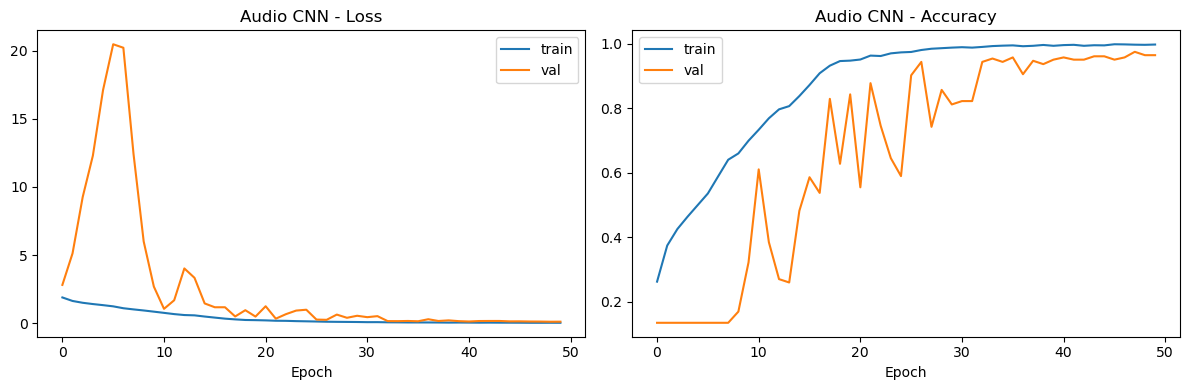

In [10]:
def plot_history(hist,title,save_as):
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    axes[0].plot(hist.history["loss"],label="train")
    axes[0].plot(hist.history["val_loss"],label="val")
    axes[0].set_title(f"{title} - Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].plot(hist.history["accuracy"],label="train")
    axes[1].plot(hist.history["val_accuracy"],label="val")
    axes[1].set_title(f"{title} - Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout(); plt.savefig(save_as,dpi=100); plt.show()

plot_history(hist_audio,"Audio CNN","audio_cnn_training.png")

## 3. Phase 1B — Whisper Transcription + Text LSTM
RAVDESS actors say the same two sentences regardless of emotion, so text alone carries very little discriminative signal — the RNN is expected to perform near chance (≈12.5%).

### 3.1 Transcribe with Whisper (cached after first run)

In [11]:
import whisper

TRANSCRIPT_CACHE="transcripts.npy"

if os.path.exists(TRANSCRIPT_CACHE):
    print("Loading cached transcripts …")
    transcripts=list(np.load(TRANSCRIPT_CACHE,allow_pickle=True))
else:
    print("Transcribing — ~10 min on CPU …")
    wm=whisper.load_model("tiny")
    transcripts=[]
    for p in tqdm(audio_paths,desc="Whisper"):
        try:
            r=wm.transcribe(p,language="en",fp16=False)
            transcripts.append(r["text"].strip().lower())
        except Exception:
            transcripts.append("")
    np.save(TRANSCRIPT_CACHE,np.array(transcripts,dtype=object))

for i in range(5):
    print(f"[{labels[i]}] {transcripts[i]}")

Transcribing — ~10 min on CPU …


Whisper: 100%|██████████| 2880/2880 [02:31<00:00, 19.06it/s]

[neutral] 
[neutral] 
[neutral] 
[neutral] 
[calm] 


### 3.2 Tokenisation & padding

In [12]:
def simple_tokenize(text):
    text=re.sub(r"[^a-z\s]","",text.lower())
    return text.split()

MAX_VOCAB=5000
MAX_LEN=30

all_tokens=[t for text in transcripts for t in simple_tokenize(text)]
vocab_counts=Counter(all_tokens)
vocab=[w for w,_ in vocab_counts.most_common(MAX_VOCAB)]
word2idx={"<PAD>":0,"<UNK>":1}
for w in vocab:
    word2idx[w]=len(word2idx)

def encode(text,w2i,maxlen):
    ids=[w2i.get(t,1) for t in simple_tokenize(text)]
    return ids[:maxlen]

sequences=[encode(t,word2idx,MAX_LEN) for t in transcripts]
X_text=pad_sequences(sequences,maxlen=MAX_LEN,padding="post",value=0)
X_text=np.array(X_text,dtype=np.int32)
VOCAB_SIZE=len(word2idx)
print("Text shape:",X_text.shape,"| Vocab:",VOCAB_SIZE)

Text shape: (2880, 30) | Vocab: 2


### 3.3 Align text splits with audio indices

In [13]:
X_txt_train=X_text[idx_train]
X_txt_val=X_text[idx_val]
X_txt_test=X_text[idx_test]

### 3.4 Text LSTM model
Embedding(64) → BiLSTM(64) → GRU(64) → Dropout → Dense(128) bottleneck.

In [14]:
def build_text_rnn(vocab_size,embed_dim,max_len,num_classes):
    inp=layers.Input(shape=(max_len,),name="text_input")
    x=layers.Embedding(vocab_size,embed_dim,mask_zero=True)(inp)
    x=layers.Bidirectional(layers.LSTM(64,return_sequences=True))(x)
    x=layers.GRU(64)(x)
    x=layers.Dropout(0.4)(x)
    x=layers.Dense(128,activation="relu",name="text_bottleneck")(x)
    out=layers.Dense(num_classes,activation="softmax",name="text_output")(x)
    return models.Model(inp,out,name="TextRNN")

text_rnn=build_text_rnn(VOCAB_SIZE,embed_dim=64,max_len=MAX_LEN,num_classes=NUM_CLASSES)
text_rnn.summary()

Model: "TextRNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 64)    │        128 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 30)        │          0 │ text_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 30, 128)   │     66,048 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 64)        │     37,248 │ bidirectional[0]… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_bottleneck     │ (None, 128)       │      8,320 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_output (Dense) │ (None, 8)         │      1,032 │ text_bottleneck[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 112,776 (440.53 KB)

 Trainable params: 112,776 (440.53 KB)

 Non-trainable params: 0 (0.00 B)

### 3.5 Train text RNN

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.1298 - loss: 2.0800 - val_accuracy: 0.1354 - val_loss: 2.0796
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.1280 - loss: 2.0799 - val_accuracy: 0.1354 - val_loss: 2.0796
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.1146 - loss: 2.0799 - val_accuracy: 0.1354 - val_loss: 2.0796
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.0916 - loss: 2.0799 - val_accuracy: 0.0660 - val_loss: 2.0796
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.0755 - loss: 2.0799 - val_accuracy: 0.0660 - val_loss: 2.0796
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.0686 - loss: 2.0799 - val_accuracy: 0.0660 - val_loss: 2.0796
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.0673 - loss: 2.0799 - val_accuracy: 0.0660 - val_loss: 2.0796
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.0716 - loss: 2.0799 - val_accuracy: 0.1319 - 

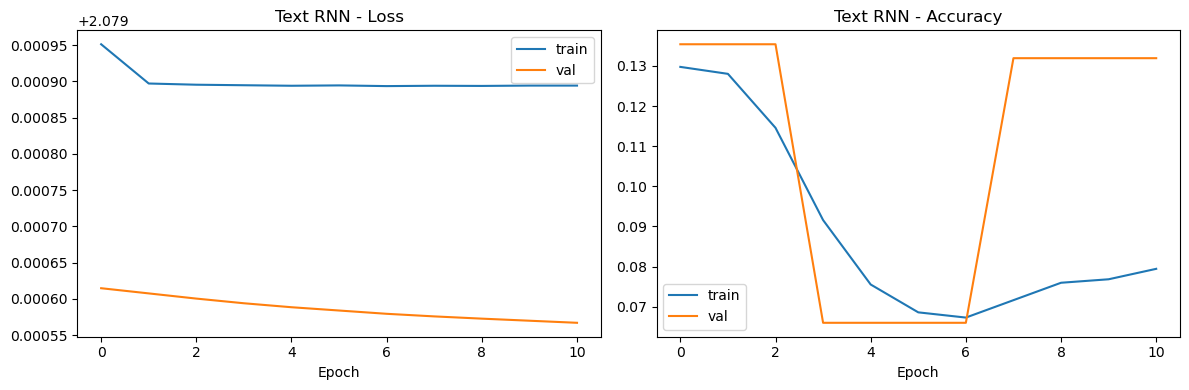

In [15]:
text_rnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss="categorical_crossentropy",metrics=["accuracy"])

ckpt_text=callbacks.ModelCheckpoint("best_text_rnn.keras",
                                    save_best_only=True,monitor="val_accuracy")
es_text=callbacks.EarlyStopping(patience=10,restore_best_weights=True,
                                monitor="val_accuracy")

hist_text=text_rnn.fit(
    X_txt_train,y_train,
    validation_data=(X_txt_val,y_val),
    epochs=50,batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[ckpt_text,es_text],
    verbose=1
)
plot_history(hist_text,"Text RNN","text_rnn_training.png")

## 4. Phase 2 — Multimodal Fusion

### 4.1 Early Fusion
Bottleneck vectors from both models are concatenated and passed through new Dense layers. **Both base models are kept trainable** so the fusion head can fine-tune them jointly (previously freezing them let the useless text branch drag accuracy down).

In [16]:
# Keep both branches trainable so fusion can re-weight their contributions
audio_cnn.trainable=True
text_rnn.trainable=True

audio_feat_model=models.Model(
    inputs=audio_cnn.input,
    outputs=audio_cnn.get_layer("audio_bottleneck").output,
    name="AudioFeatures"
)
text_feat_model=models.Model(
    inputs=text_rnn.input,
    outputs=text_rnn.get_layer("text_bottleneck").output,
    name="TextFeatures"
)

def build_early_fusion(audio_input_shape,text_max_len,num_classes):
    aud_in=layers.Input(shape=audio_input_shape,name="audio_in")
    txt_in=layers.Input(shape=(text_max_len,),name="text_in")
    aud_feat=audio_feat_model(aud_in)
    txt_feat=text_feat_model(txt_in)
    merged=layers.Concatenate(name="concat")([aud_feat,txt_feat])
    x=layers.Dense(128,activation="relu")(merged)
    x=layers.Dropout(0.3)(x)
    x=layers.Dense(64,activation="relu")(x)
    out=layers.Dense(num_classes,activation="softmax",name="early_output")(x)
    return models.Model([aud_in,txt_in],out,name="EarlyFusion")

early_fusion=build_early_fusion(X_audio.shape[1:],MAX_LEN,NUM_CLASSES)
early_fusion.summary()

Model: "EarlyFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_in            │ (None, 64, 130,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_in             │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ AudioFeatures       │ (None, 128)       │    110,080 │ audio_in[0][0]    │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ TextFeatures        │ (None, 128)       │    111,744 │ text_in[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 256)       │          0 │ AudioFeatures[0]… │
│ (Concatenate)       │                   │            │ TextFeatures[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_output        │ (None, 8)         │        520 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 263,496 (1.01 MB)

 Trainable params: 263,048 (1.00 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 62s 536ms/step - accuracy: 0.6202 - loss: 1.1548 - val_accuracy: 0.6146 - val_loss: 0.9647
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 566ms/step - accuracy: 0.9145 - loss: 0.3416 - val_accuracy: 0.4583 - val_loss: 2.4914
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 579ms/step - accuracy: 0.9384 - loss: 0.2203 - val_accuracy: 0.3090 - val_loss: 4.0593
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 565ms/step - accuracy: 0.9536 - loss: 0.1641 - val_accuracy: 0.7396 - val_loss: 0.7016
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 542ms/step - accuracy: 0.9505 - loss: 0.1600 - val_accuracy: 0.4653 - val_loss: 3.3674
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 579ms/step - accuracy: 0.9648 - loss: 0.1157 - val_accuracy: 0.7882 - val_loss: 0.7408
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 552ms/step - accuracy: 0.9479 - loss: 0.1539 - val_accuracy: 0.6910 - val_loss: 0.7978
Epoch 8/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 542ms/step - accuracy: 0.9588 - loss: 0.1229 - val_accu

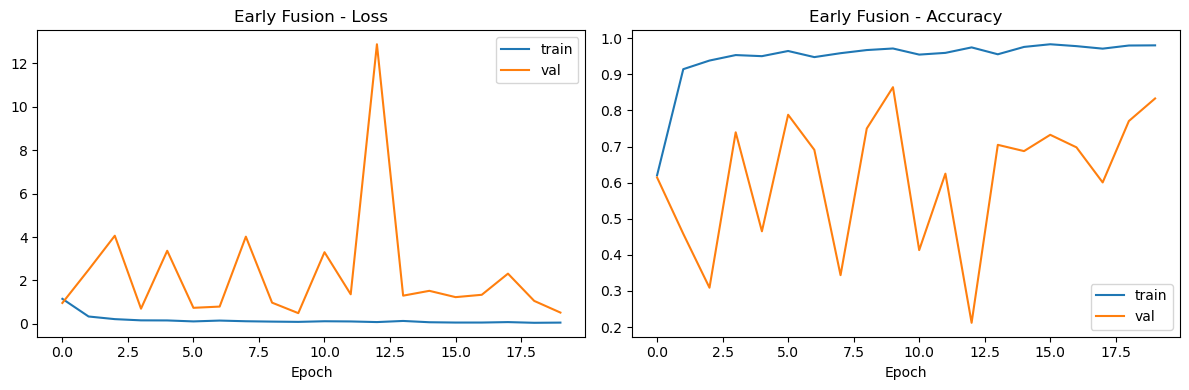

In [17]:
early_fusion.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                     loss="categorical_crossentropy",metrics=["accuracy"])

ckpt_early=callbacks.ModelCheckpoint("best_early_fusion.keras",
                                     save_best_only=True,monitor="val_accuracy")
es_early=callbacks.EarlyStopping(patience=10,restore_best_weights=True,
                                 monitor="val_accuracy")

hist_early=early_fusion.fit(
    [X_aud_train,X_txt_train],y_train,
    validation_data=([X_aud_val,X_txt_val],y_val),
    epochs=40,batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[ckpt_early,es_early],
    verbose=1
)
plot_history(hist_early,"Early Fusion","early_fusion_training.png")

### 4.2 Late Fusion — probability-level combination

In [18]:
prob_audio=audio_cnn.predict(X_aud_test,verbose=0)
prob_text=text_rnn.predict(X_txt_test,verbose=0)

prob_avg=(prob_audio+prob_text)/2.0
prob_weighted=0.7*prob_audio+0.3*prob_text

conf_audio=prob_audio.max(axis=1)
conf_text=prob_text.max(axis=1)
prob_maxrule=np.where(
    conf_audio[:,np.newaxis]>=conf_text[:,np.newaxis],
    prob_audio,prob_text
)

## 5. Phase 3 — Evaluation & Comparison

In [19]:
y_test_int=np.argmax(y_test,axis=1)

def evaluate(name,probs,y_true):
    preds=np.argmax(probs,axis=1)
    acc=accuracy_score(y_true,preds)
    report=classification_report(y_true,preds,target_names=le.classes_,
                                 output_dict=True,zero_division=0)
    macro_f1=report["macro avg"]["f1-score"]
    print(f"\n{'='*50}\n  {name}\n  Accuracy:{acc:.4f}  Macro-F1:{macro_f1:.4f}\n{'='*50}")
    print(classification_report(y_true,preds,target_names=le.classes_,zero_division=0))
    return acc,macro_f1,preds

prob_early_test=early_fusion.predict([X_aud_test,X_txt_test],verbose=0)

results={}
results["Audio CNN"],_,preds_audio=evaluate("Audio-Only CNN",prob_audio,y_test_int)
results["Text RNN"],_,preds_text=evaluate("Text-Only RNN",prob_text,y_test_int)
results["Early Fusion"],_,preds_early=evaluate("Early Fusion",prob_early_test,y_test_int)
results["Late Avg"],_,preds_avg=evaluate("Late Fusion (Avg)",prob_avg,y_test_int)
results["Late Weighted"],_,preds_wtd=evaluate("Late Fusion (0.7/0.3)",prob_weighted,y_test_int)
results["Late MaxRule"],_,preds_max=evaluate("Late Fusion (MaxRule)",prob_maxrule,y_test_int)


  Audio-Only CNN
  Accuracy:0.8542  Macro-F1:0.8489
              precision    recall  f1-score   support

       angry       0.86      0.95      0.90        38
        calm       0.97      0.84      0.90        38
     disgust       1.00      0.89      0.94        38
     fearful       0.85      0.90      0.88        39
       happy       0.70      0.95      0.80        39
     neutral       0.86      1.00      0.93        19
         sad       1.00      0.38      0.56        39
   surprised       0.79      1.00      0.88        38

    accuracy                           0.85       288
   macro avg       0.88      0.86      0.85       288
weighted avg       0.88      0.85      0.84       288


  Text-Only RNN
  Accuracy:0.1319  Macro-F1:0.0291
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        38
        calm       0.00      0.00      0.00        38
     disgust       0.13      1.00      0.23        38
     fearful       0.00    

### 5.1 Accuracy bar chart

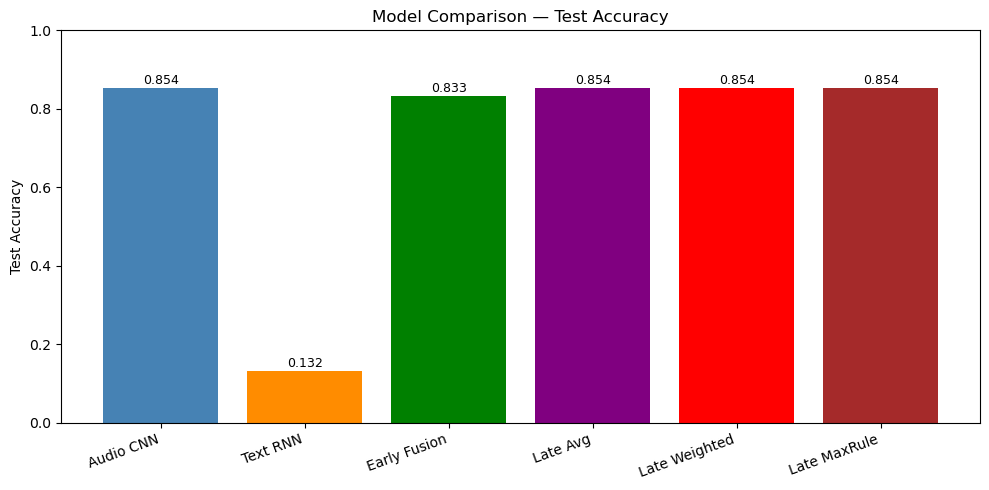

In [20]:
plt.figure(figsize=(10,5))
names=list(results.keys())
accs=[results[n] for n in names]
bars=plt.bar(names,accs,color=["steelblue","darkorange","green","purple","red","brown"])
plt.ylim(0,1); plt.xticks(rotation=20,ha="right"); plt.ylabel("Test Accuracy")
plt.title("Model Comparison — Test Accuracy")
for bar,acc in zip(bars,accs):
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,
             f"{acc:.3f}",ha="center",fontsize=9)
plt.tight_layout(); plt.savefig("model_comparison.png",dpi=100); plt.show()

### 5.2 Confusion matrices

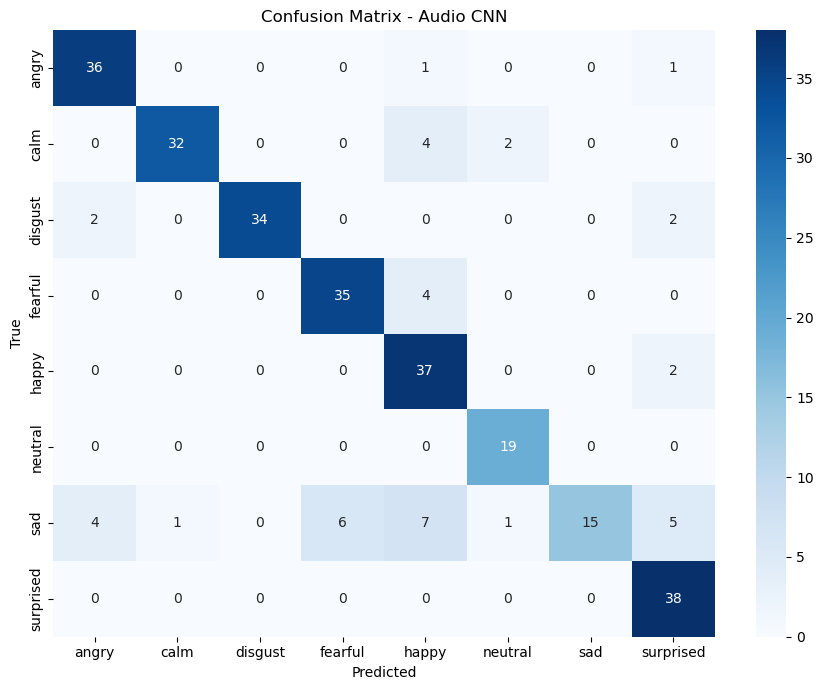

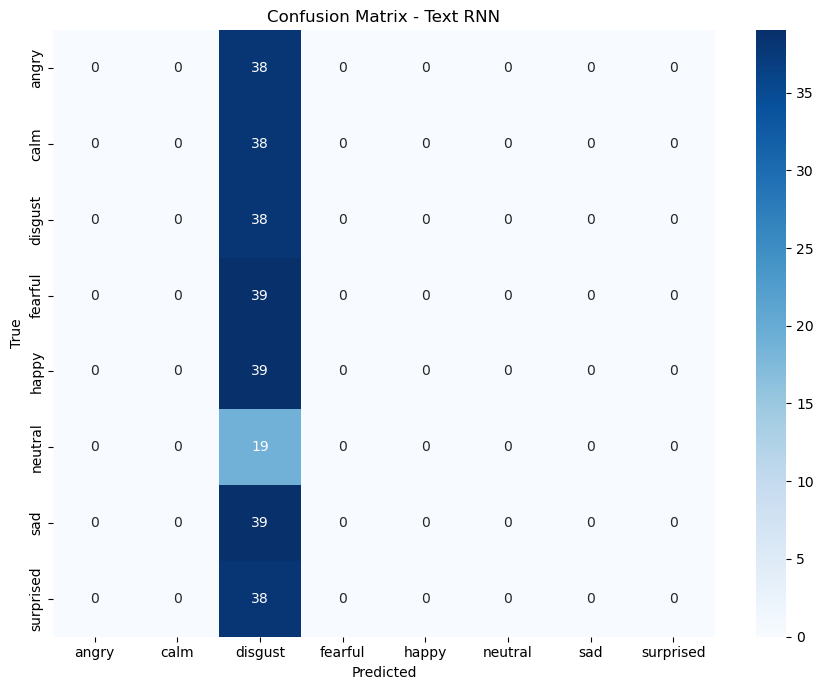

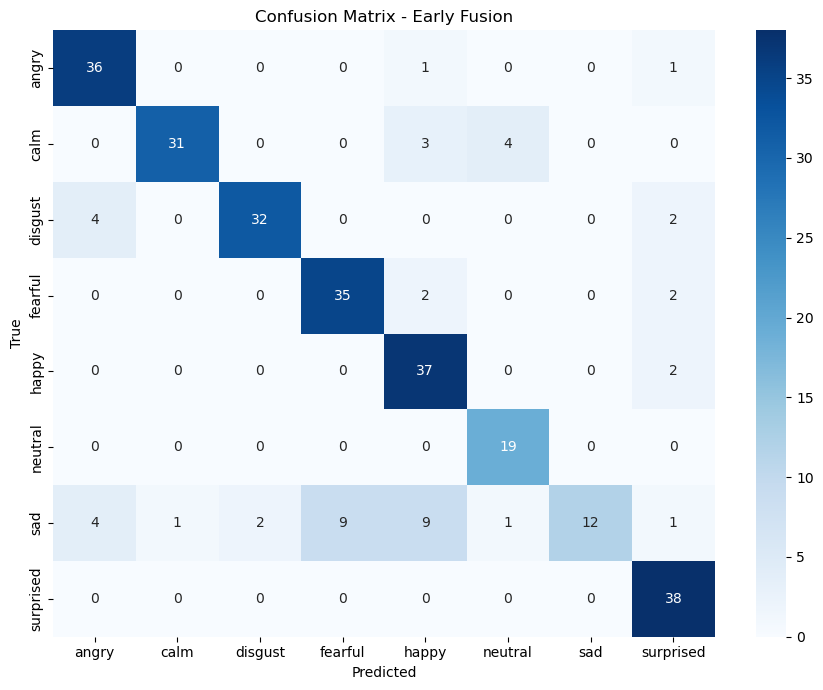

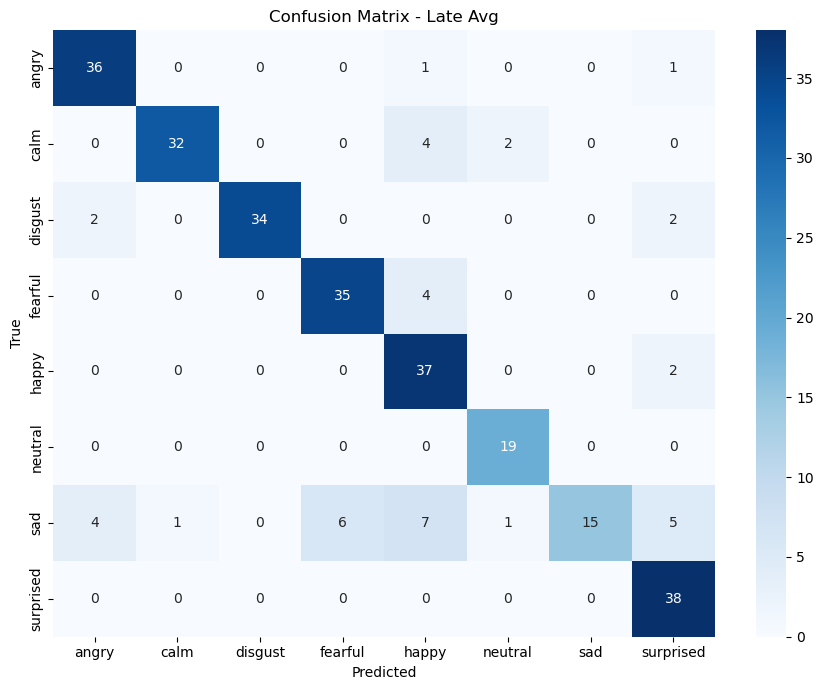

In [21]:
def plot_cm(y_true,y_pred,title,save_as):
    cm=confusion_matrix(y_true,y_pred)
    plt.figure(figsize=(9,7))
    sns.heatmap(cm,annot=True,fmt="d",
                xticklabels=le.classes_,yticklabels=le.classes_,cmap="Blues")
    plt.title(title); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.savefig(save_as,dpi=100); plt.show()

plot_cm(y_test_int,preds_audio,"Confusion Matrix - Audio CNN","cm_audio.png")
plot_cm(y_test_int,preds_text,"Confusion Matrix - Text RNN","cm_text.png")
plot_cm(y_test_int,preds_early,"Confusion Matrix - Early Fusion","cm_early.png")
plot_cm(y_test_int,preds_avg,"Confusion Matrix - Late Avg","cm_late_avg.png")

## 6. Bonus — Data Augmentation
Gaussian noise + SpecAugment-style time/frequency masking doubles the training set. Checks if the CNN remains robust to acoustic variation.

In [22]:
def augment_spectrogram(spec):
    aug=spec.copy()
    aug=aug+0.005*np.random.randn(*aug.shape)
    t_start=np.random.randint(0,aug.shape[1]//2)
    t_width=np.random.randint(5,15)
    aug[:,t_start:t_start+t_width,:]=0.0
    f_start=np.random.randint(0,aug.shape[0]//2)
    f_width=np.random.randint(4,10)
    aug[f_start:f_start+f_width,:,:]=0.0
    return np.clip(aug,0,1)

print("Building augmented training set …")
X_aud_aug=np.array([augment_spectrogram(s) for s in X_aud_train],dtype=np.float32)
X_aud_train_aug=np.concatenate([X_aud_train,X_aud_aug],axis=0)
y_train_aug=np.concatenate([y_train,y_train],axis=0)
y_int_aug=np.concatenate([y_int[idx_train],y_int[idx_train]])
cw_aug=compute_class_weight("balanced",classes=np.unique(y_int_aug),y=y_int_aug)
cw_aug_dict={i:w for i,w in enumerate(cw_aug)}

Building augmented training set …


In [ ]:
audio_cnn_aug=build_audio_cnn(X_audio.shape[1:],NUM_CLASSES)
audio_cnn_aug.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss="categorical_crossentropy",metrics=["accuracy"])

ckpt_aug=callbacks.ModelCheckpoint("best_audio_cnn_aug.keras",
                                   save_best_only=True,monitor="val_accuracy")
es_aug=callbacks.EarlyStopping(patience=10,restore_best_weights=True,
                               monitor="val_accuracy")

hist_aug=audio_cnn_aug.fit(
    X_aud_train_aug,y_train_aug,
    validation_data=(X_aud_val,y_val),
    epochs=50,batch_size=32,
    class_weight=cw_aug_dict,
    callbacks=[ckpt_aug,es_aug],
    verbose=1
)
plot_history(hist_aug,"Augmented Audio CNN","audio_cnn_aug_training.png")

prob_audio_aug=audio_cnn_aug.predict(X_aud_test,verbose=0)
acc_aug,_,_=evaluate("Augmented Audio CNN",prob_audio_aug,y_test_int)
print(f"Augmented model test accuracy: {acc_aug:.4f}")

Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 66s 420ms/step - accuracy: 0.2480 - loss: 1.9098 - val_accuracy: 0.1354 - val_loss: 5.3621
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 60s 416ms/step - accuracy: 0.3657 - loss: 1.6332 - val_accuracy: 0.1319 - val_loss: 9.9548
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 62s 429ms/step - accuracy: 0.4355 - loss: 1.4806 - val_accuracy: 0.1354 - val_loss: 11.8692
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 56s 390ms/step - accuracy: 0.4985 - loss: 1.3232 - val_accuracy: 0.1458 - val_loss: 12.8189
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 56s 389ms/step - accuracy: 0.5516 - loss: 1.1900 - val_accuracy: 0.1632 - val_loss: 4.6233
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 54s 377ms/step - accuracy: 0.6037 - loss: 1.0398 - val_accuracy: 0.1458 - val_loss: 4.2511
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 56s 386ms/step - accuracy: 0.6604 - loss: 0.9147 - val_accuracy: 0.2986 - val_loss: 2.1217
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 55s 380ms/step - accuracy: 0.7237 - loss:

## 7. Bonus — DistilBERT Text Branch (optional)
Uncomment to replace the vanilla LSTM with a pre-trained DistilBERT. Requires `pip install transformers` and ~4 GB RAM.

In [ ]:
# !pip install transformers -q

# from transformers import DistilBertTokenizerFast,TFDistilBertForSequenceClassification
#
# BERT_MAX_LEN=64
# tokenizer=DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
#
# def encode_bert(texts,tokenizer,max_len):
#     enc=tokenizer(list(texts),max_length=max_len,
#                   padding="max_length",truncation=True,return_tensors="tf")
#     return enc["input_ids"],enc["attention_mask"]
#
# train_ids,train_mask=encode_bert([transcripts[i] for i in idx_train],tokenizer,BERT_MAX_LEN)
# val_ids,val_mask=encode_bert([transcripts[i] for i in idx_val],tokenizer,BERT_MAX_LEN)
# test_ids,test_mask=encode_bert([transcripts[i] for i in idx_test],tokenizer,BERT_MAX_LEN)
#
# bert_model=TFDistilBertForSequenceClassification.from_pretrained(
#     "distilbert-base-uncased",num_labels=NUM_CLASSES)
# bert_model.compile(
#     optimizer=tf.keras.optimizers.Adam(2e-5),
#     loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
#     metrics=["accuracy"]
# )
# bert_model.fit({"input_ids":train_ids,"attention_mask":train_mask},y_train,
#                validation_data=({"input_ids":val_ids,"attention_mask":val_mask},y_val),
#                epochs=5,batch_size=16)
#
# logits=bert_model.predict({"input_ids":test_ids,"attention_mask":test_mask}).logits
# prob_bert=tf.nn.softmax(logits).numpy()
# acc_bert,_,_=evaluate("DistilBERT Text",prob_bert,y_test_int)
print("DistilBERT section is commented out — uncomment to run.")

## 8. Final Results Summary

In [25]:
print("\n"+"="*55)
print("         FINAL RESULTS SUMMARY")
print("="*55)
print(f"{'Model':<35} {'Accuracy':>10}")
print("-"*55)
for name,acc in results.items():
    print(f"{name:<35} {acc:>10.4f}")
print("="*55)


         FINAL RESULTS SUMMARY
Model                                 Accuracy
-------------------------------------------------------
Audio CNN                               0.8542
Text RNN                                0.1319
Early Fusion                            0.8333
Late Avg                                0.8542
Late Weighted                           0.8542
Late MaxRule                            0.8542
